In [31]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

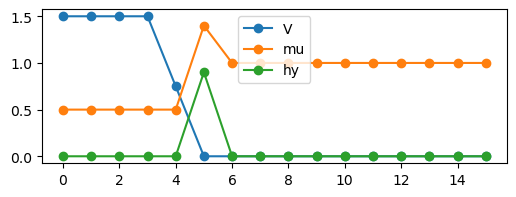

In [32]:
widthS = 5
widthF1 = 1
widthF2 = 10
X, Y = widthS+widthF1+widthF2, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 0.5 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS+widthF1] = muF
mu[widthS+widthF1:] = muN

h0 = 0.9 * t
hy = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = h0

U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [33]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1], hy=hy)

In [34]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 0.044650206869078536
Relative error: 44650206869.07853
Average old: 0j
Average: (0.00423265025988972+6.8987485175320095e-18j)
F_xplus:
Absolute error: 0.18249551970399594
Relative error: 35717398101.46083
Average old: (0.02666666666666667+0j)
Average: (0.05516957548432501-7.434319622447162e-19j)
F_xmin:
Absolute error: 0.1927957131740187
Relative error: 26348339873.510376
Average old: (0.03333333333333333+0j)
Average: (0.059704772227884215-3.4491677869682415e-18j)
F_yplus:
Absolute error: 0.16510559615736106
Relative error: 35322420134.90464
Average old: (-0.03125+0j)
Average: (-0.05782795258397611-1.171193229576836e-16j)
F_ymin:
Absolute error: 0.16510559615736112
Relative error: 35322420134.904755
Average old: (-0.03125+0j)
Average: (-0.05782795258397615+1.2358850479891716e-16j)
Fuu_xplus:
Absolute error: 0.02169221391194656
Relative error: 21692213911.94656
Average old: 0j
Average: (3.08060633341745e-18-0.004081381200632373j)
Fuu_xmin:
Absolute error: 0.021692213

In [35]:
F, Fuu, Fdd = H.get_correlations()

T/t=0.001, hy/t=0.9


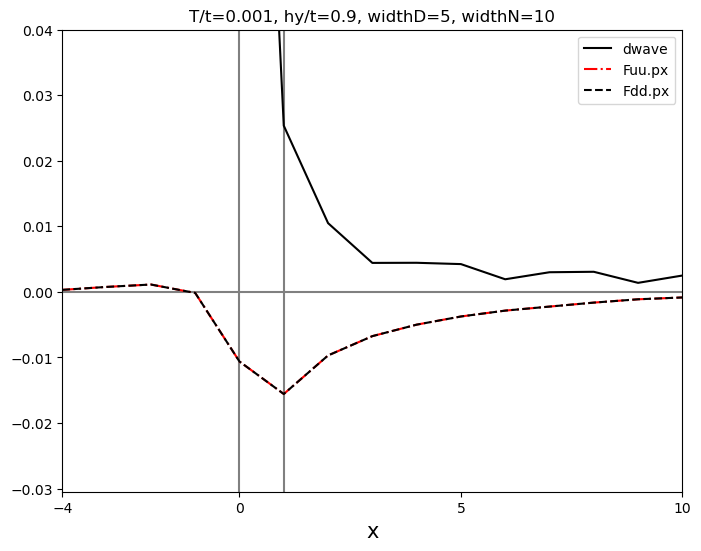

In [36]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
# axs.plot(x, np.real(F.px), label=r"px", color='red')
axs.plot(x, np.imag(Fuu.px), "-.", label=r"Fuu.px", color='red')
axs.plot(x, np.imag(Fdd.px), "--", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)
axs.set_title(f"T/t={T}, hy/t={h0}, widthD={widthS}, widthN={widthF2}", )

axs.set_ylim(None, 0.04)
axs.set_xlim(-4, 10)
axs.set_xticks([-4, 0, 5, 10])
plt.legend()
plt.show()

In [37]:
F1, Fuu1, Fdd1 = H.get_correlations()

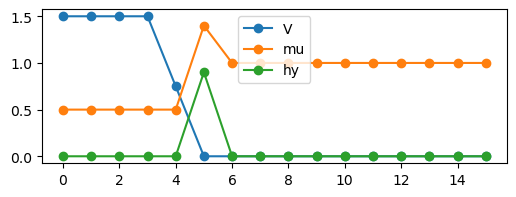

In [38]:
widthS = 5
widthF1 = 1
widthF2 = 10
X, Y = widthS+widthF1+widthF2, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muS = 0.5 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS+widthF1] = muF
mu[widthS+widthF1:] = muN

h0 = 0.9 * t
hy = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = h0

U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [39]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1], hx=hy)

In [40]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 0.044650206869079646
Relative error: 44650206869.07964
Average old: 0j
Average: (0.004232650259889902+0j)
F_xplus:
Absolute error: 0.18249551970399774
Relative error: 35717398101.46094
Average old: (0.02666666666666667+0j)
Average: (0.05516957548432519+0j)
F_xmin:
Absolute error: 0.1927957131740194
Relative error: 26348339873.51059
Average old: (0.03333333333333333+0j)
Average: (0.059704772227884256+0j)
F_yplus:
Absolute error: 0.16510559615736253
Relative error: 35322420134.904655
Average old: (-0.03125+0j)
Average: (-0.05782795258397629-1.6786263917805715e-16j)
F_ymin:
Absolute error: 0.16510559615736253
Relative error: 35322420134.904655
Average old: (-0.03125+0j)
Average: (-0.05782795258397629+1.6786263917805715e-16j)
Fuu_xplus:
Absolute error: 0.021692213911946492
Relative error: 21692213911.94649
Average old: 0j
Average: (0.004081381200632183+0j)
Fuu_xmin:
Absolute error: 0.021692213911946708
Relative error: 21692213911.946712
Average old: 0j
Average: (-0.0040

In [41]:
F, Fuu, Fdd = H.get_correlations()

T/t=0.001, hy/t=0.9


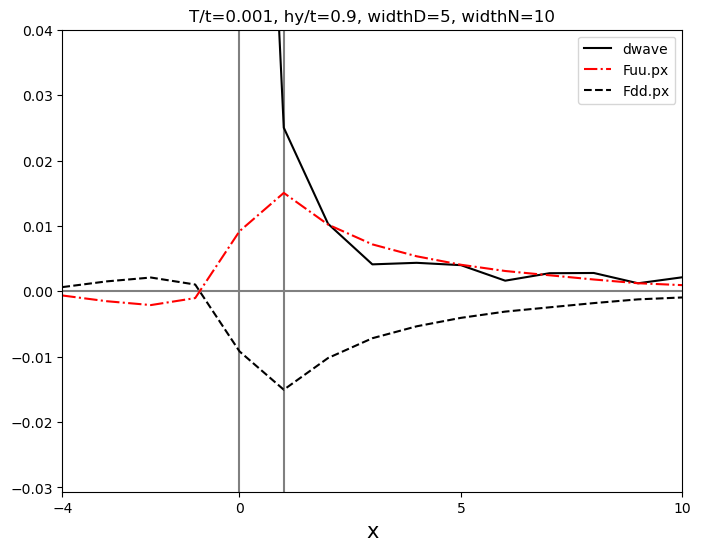

In [ ]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
# axs.plot(x, np.real(F.px), label=r"px", color='red')
axs.plot(x, np.real(Fuu.px), "-.", label=r"Fuu.px", color='red')
axs.plot(x, np.real(Fdd.px), "--", label=r"Fdd.px", color='black')

axs.set_xlabel("x", fontsize=15)

axs.set_ylim(None, 0.04)
axs.set_xlim(-4, 10)
axs.set_xticks([-4, 0, 5, 10])
plt.legend()
plt.show()

In [43]:
F2, Fuu2, Fdd2 = H.get_correlations()

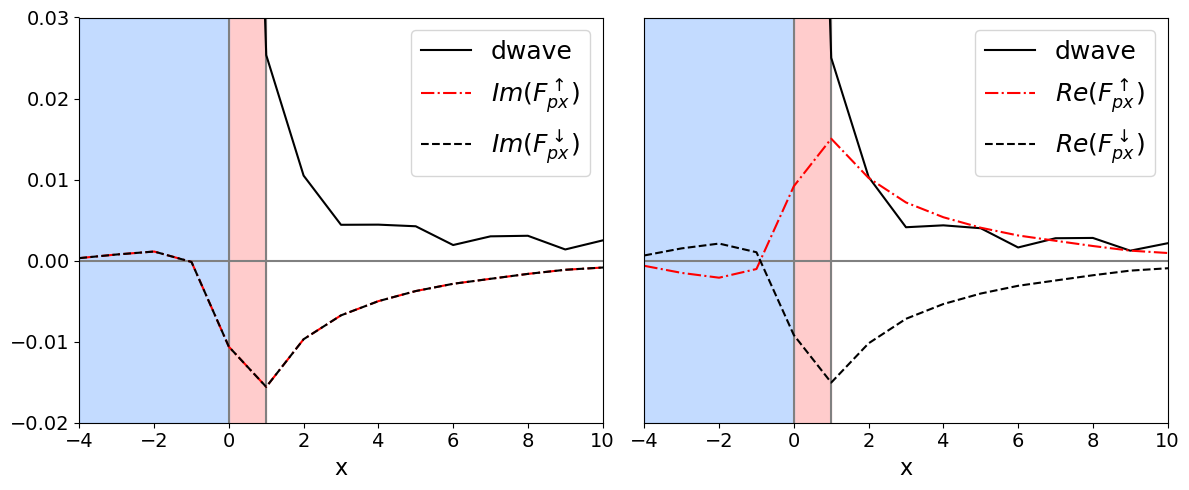

In [72]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].axhline(0, color='gray')
axs[0].axvline(0, color='gray')
axs[0].axvline(widthF1, color='gray')

axs[0].plot(x, np.abs(F1.dwave), label=r"dwave", color='black')
axs[0].plot(x, np.imag(Fuu1.px), "-.", label=r"$Im(F^{\uparrow}_{px})$", color='red')
axs[0].plot(x, np.imag(Fdd1.px), "--", label=r"$Im(F^{\downarrow}_{px})$", color='black')

axs[0].set_xlabel("x", fontsize=16)
axs[0].set_ylim(-0.02, 0.03)
axs[0].set_xlim(-4, 10)
axs[0].tick_params(axis='x', labelsize=14)
axs[0].tick_params(axis='y', labelsize=14)
axs[0].legend(fontsize=18)
axs[0].axvspan(0, 1, color='#FFCCCC', alpha=1)
axs[0].axvspan(-4, 0, color='#89B9FF', alpha=0.5)


axs[1].axhline(0, color='gray')
axs[1].axvline(0, color='gray')
axs[1].axvline(widthF1, color='gray')

axs[1].plot(x, np.abs(F2.dwave), label=r"dwave", color='black')
axs[1].plot(x, np.real(Fuu2.px), "-.", label=r"$Re(F^{\uparrow}_{px})$", color='red')
axs[1].plot(x, np.real(Fdd2.px), "--", label=r"$Re(F^{\downarrow}_{px})$", color='black')

axs[1].set_xlabel("x", fontsize=16)
axs[1].set_ylim(-0.02, 0.03)
axs[1].set_xlim(-4, 10)
axs[1].set_yticks([])
axs[1].tick_params(axis='x', labelsize=14)
axs[1].legend(fontsize=18)
axs[1].axvspan(0, 1, color='#FFCCCC', alpha=1)
axs[1].axvspan(-4, 0, color='#89B9FF', alpha=0.5)


plt.tight_layout()
plt.savefig("../figures/DFN_small.svg", bbox_inches='tight')